### I. Giới thiệu
Các mô hình tuyến tính như Linear Regression hay Perceptron Learning Algorithm (PLA) có những hạn chế nhất định khi giải quyết bài toán phân loại. Linear Regression cho đầu ra không bị chặn, dẫn đến việc phân lớp cứng nhắc và dễ bị nhiễu bởi các điểm dữ liệu ngoại lai (outliers). PLA chỉ hoạt động khi dữ liệu phân chia tuyến tính hoàn toàn (linearly separable).

Logistic Regression ra đời để khắc phục các nhược điểm này bằng cách:
* Đưa đầu ra về dạng xác suất (bị chặn trong khoảng từ 0 đến 1).
* Làm mượt (smooth) ranh giới quyết định, giúp mô hình linh hoạt hơn.

**Bài toán thực nghiệm:** Đánh giá xác suất đỗ kỳ thi của một nhóm 20 sinh viên dựa trên số giờ ôn tập (từ 0 đến 6 giờ).

### II. CƠ SỞ LÝ THUYẾT

### 2.1. Hàm Kích Hoạt Sigmoid
Để ép giá trị tuyến tính $z = w^T x$ về khoảng $(0, 1)$, Logistic Regression sử dụng hàm Sigmoid (logistic function):
$$\sigma(s) = \frac{1}{1 + e^{-s}}$$
Hàm số này có tính chất quan trọng là liên tục, mượt và có đạo hàm tại mọi điểm: $\sigma'(s) = \sigma(s)(1 - \sigma(s))$, rất thuận lợi cho việc tối ưu hóa.

### 2.2. Hàm Mất Mát Cross-Entropy (Loss Function)
Vì đầu ra là xác suất, chúng ta tối ưu hóa mô hình bằng phương pháp Maximum Likelihood Estimation (MLE). Khi chuyển qua bài toán tìm giá trị nhỏ nhất, ta thu được hàm mất mát Cross-Entropy:
$$J(w) = - \sum_{i=1}^N \left( y_i \log(z_i) + (1 - y_i) \log(1 - z_i) \right)$$
Trong đó $y_i$ là nhãn thực tế (0 hoặc 1), và $z_i = \sigma(w^T x_i)$ là xác suất mô hình dự đoán.

### 2.3. Tối ưu hóa bằng Gradient Descent
Đạo hàm của hàm mất mát theo $w$ có dạng:
$$\nabla_w J(w) = X (Z - Y)^T$$
Sử dụng Stochastic Gradient Descent (SGD) để cập nhật trọng số cho từng điểm dữ liệu:
$$w_{new} = w_{old} + \eta (y_i - z_i) x_i$$
Với $\eta$ là learning rate.


### III. Ví dụ mô hình

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Khởi tạo dữ liệu
np.random.seed(2)
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# Thêm bias (x0 = 1)
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

# 2. Xây dựng hàm
def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            if count % check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w

# 3. Huấn luyện mô hình
eta = 0.05 
d = X.shape[0]
w_init = np.random.randn(d, 1)
w = logistic_sigmoid_regression(X, y, w_init, eta)

print("Trọng số w tìm được:\n", w[-1])

Trọng số w tìm được:
 [[-4.092695  ]
 [ 1.55277242]]


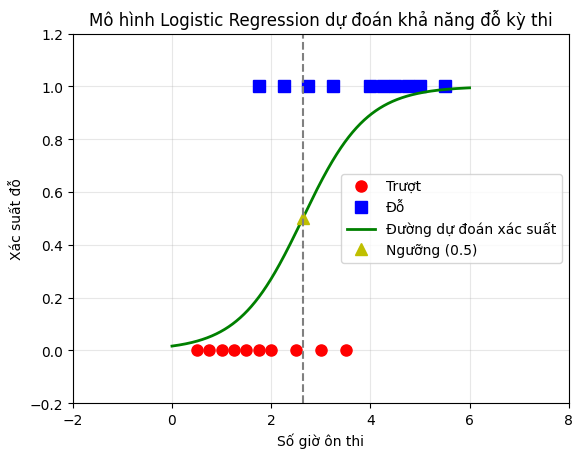

In [2]:
# vẽ đồ thị hàm Sigmoid với các trọng số w vừa tìm được lồng ghép lên tập dữ liệu ban đầu.
X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8, label="Trượt")
plt.plot(X1, y1, 'bs', markersize = 8, label="Đỗ")

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)

plt.axis([-2, 8, -0.2, 1.2])
plt.plot(xx, yy, 'g-', linewidth = 2, label="Đường dự đoán xác suất")
plt.plot(threshold, .5, 'y^', markersize = 8, label="Ngưỡng (0.5)")
plt.axvline(x=threshold, color='gray', linestyle='--')

plt.xlabel('Số giờ ôn thi')
plt.ylabel('Xác suất đỗ')
plt.legend()
plt.title("Mô hình Logistic Regression dự đoán khả năng đỗ kỳ thi")
plt.grid(True, alpha=0.3)
plt.show()

### IV. KẾT LUẬN

Đồ thị thực nghiệm cho thấy đường cong màu xanh lá (hàm sigmoid) bám sát sự phân bổ của dữ liệu. Điểm giao cắt tại ngưỡng xác suất `0.5` (hình tam giác vàng) đóng vai trò là ranh giới quyết định (decision boundary). 
* Nếu học trên mức này (khoảng > 2.6 giờ), mô hình dự đoán xác suất đỗ lớn hơn 50%.
* Mô hình cho thấy tính ưu việt hơn hẳn Linear Regression vì đầu ra luôn nằm trong giới hạn thực tế của xác suất $(0, 1)$ và không bị kéo lệch bởi các điểm ngoại lai.

Dù tên gọi là "Regression", thực chất thuật toán này là một trong những công cụ cơ bản và mạnh mẽ nhất cho bài toán phân loại nhị phân trong Machine Learning.

### V. BÀI TẬP

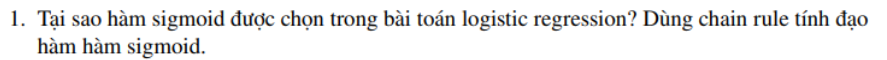

1. Tại sao chọn hàm Sigmoid?
* Bóp mọi giá trị đầu ra tuyến tính $z = w^T x$ (từ $-\infty$ đến $+\infty$) về khoảng $(0, 1)$, phù hợp với ý nghĩa của xác suất.
* Là hàm liên tục, trơn mượt và có đạo hàm tại mọi điểm, thuận lợi cho các thuật toán tối ưu như Gradient Descent.

2. Đạo hàm bằng Chain rule
Cho hàm $\sigma(z) = (1 + e^{-z})^{-1}$. Đặt $u = 1 + e^{-z}$.
Theo quy tắc chuỗi: $\frac{d\sigma}{dz} = \frac{d\sigma}{du} \cdot \frac{du}{dz}$
$$\sigma'(z) = \left[ -1 \cdot (1 + e^{-z})^{-2} \right] \cdot (-e^{-z})$$
$$\sigma'(z) = \frac{e^{-z}}{(1 + e^{-z})^2} = \left( \frac{1}{1 + e^{-z}} \right) \cdot \left( \frac{e^{-z}}{1 + e^{-z}} \right)$$
Thêm bớt 1 vào tử số của phân số thứ hai:
$$\sigma'(z) = \sigma(z) \cdot \left( \frac{1 + e^{-z} - 1}{1 + e^{-z}} \right) = \sigma(z)(1 - \sigma(z))$$

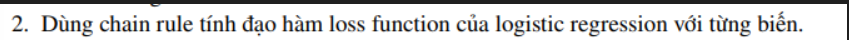

Xét Loss function (Cross-Entropy) cho 1 điểm dữ liệu: 
$$L = -[y \log(z) + (1-y) \log(1-z)]$$
Với $z = \sigma(s)$ và $s = w^T x = \sum w_j x_j$.

Áp dụng Chain rule để tính đạo hàm theo từng biến trọng số $w_j$:
$$\frac{\partial L}{\partial w_j} = \frac{\partial L}{\partial z} \cdot \frac{\partial z}{\partial s} \cdot \frac{\partial s}{\partial w_j}$$

**Tính từng thành phần:**
1. $\frac{\partial L}{\partial z} = -\left( \frac{y}{z} - \frac{1-y}{1-z} \right) = \frac{z-y}{z(1-z)}$
2. $\frac{\partial z}{\partial s} = \sigma'(s) = z(1-z)$
3. $\frac{\partial s}{\partial w_j} = x_j$

**Nhân lại ta được kết quả rút gọn:**
$$\frac{\partial L}{\partial w_j} = \left( \frac{z-y}{z(1-z)} \right) \cdot z(1-z) \cdot x_j = (z - y)x_j$$

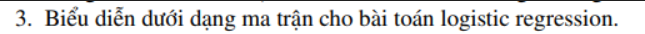

Giả sử tập dữ liệu $X \in \mathbb{R}^{d \times N}$ ($d$ là số đặc trưng, $N$ là số điểm dữ liệu), nhãn $Y \in \mathbb{R}^{1 \times N}$, và vector trọng số $w \in \mathbb{R}^{d \times 1}$.

1. Dự đoán xác suất (Ma trận $Z$):

$$Z = \sigma(w^T X)$$

*(Với $Z \in \mathbb{R}^{1 \times N}$)*

2. Hàm mất mát Cross-Entropy (Toàn bộ tập dữ liệu):

$$J(w) = -\frac{1}{N} \sum_{i=1}^N \left( y_i \log(z_i) + (1-y_i) \log(1-z_i) \right)$$

3. Đạo hàm (Gradient) dạng ma trận:

$$\nabla_w J(w) = \frac{1}{N} X(Z - Y)^T$$

*(Gradient sẽ trả về một vector có kích thước giống hệt vector $w$ ban đầu là $d \times 1$)*

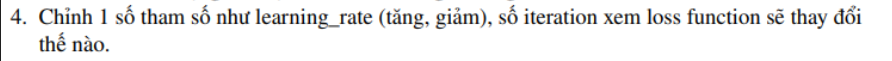

* Learning rate ($\eta$):
  * Tăng $\eta$ quá lớn: Bước cập nhật trọng số quá dài khiến hàm Loss bị "nhảy" qua lại quanh điểm cực tiểu (dao động mạnh), không thể hội tụ, thậm chí có thể phân kỳ (Loss tăng dần đến vô cực).
  * Giảm $\eta$ quá nhỏ: Bước cập nhật cực kỳ ngắn, hàm Loss giảm cực kỳ chậm. Mô hình sẽ tốn rất nhiều thời gian (iterations) để hội tụ, hoặc có thể bị kẹt lại trước khi đạt điểm tối ưu.

* Số Iterations (Số vòng lặp):
  * Tăng số vòng lặp: Hàm loss sẽ có nhiều cơ hội để giảm dần và tiến tới điểm hội tụ (khi đó loss sẽ đi ngang).
  * Giảm số vòng lặp: Mô hình có thể dừng cập nhật khi hàm loss vẫn còn cao (chưa tối ưu), dẫn đến hiện tượng underfitting (mô hình dự đoán kém).
[Cell 5 - Bài 5]